# Protein Folding Inference

The goal of this notebook is to take one held-out protein sequence and run the complete single-chain inference path. We'll randomly select a sequence from the test shard, rebuild the model inputs from that sequence alone, run the recycling trunk and full diffusion sampler, and inspect the predicted coordinates and confidence outputs. At the end we'll bring back the cached target coordinates so we can compare the prediction against the known structure.

The model operations behind this inference pass are unfolded in [3a_train_foldingcore.ipynb](3a_train_foldingcore.ipynb), [3b_train_diffusionhead.ipynb](3b_train_diffusionhead.ipynb), and [3c_train_confidencehead.ipynb](3c_train_confidencehead.ipynb). Here we'll use the assembled `ProteinFolding.sample` path rather than repeat those layers.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import py3Dmol
import torch

from model.protein_folding import (
    ATOM_SLOTS,
    ProteinFolding,
    ProteinFoldingConfig,
    folding_model_inputs,
    make_atom_feature_batch,
    write_atom_pdb,
)
from model.protein_tokenizer import ProteinTokenizer

## Setup

We'll use one seed for randomly selecting the test sequence and another seed for diffusion sampling. Keeping them separate means we can rerun the same protein with a different structure-sampling seed later.

In [2]:
SELECTION_SEED = 1337
INFERENCE_SEED = 2025

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data_root = Path('~/data/protein_folding').expanduser()
test_shard_root = data_root / 'tokenized' / 'test'
checkpoint_path = data_root / 'checkpoint' / 'protein_folding_confidence.pt'
output_root = data_root / 'inference_examples'
output_root.mkdir(parents=True, exist_ok=True)

device, checkpoint_path

(device(type='cpu'),
 PosixPath('/Users/djemec/data/protein_folding/checkpoint/protein_folding_confidence.pt'))

## Load the Confidence-Trained Folding Model

The confidence checkpoint stores the complete model configuration and full model state, including the trained confidence-head parameters. We'll rebuild the exact architecture used during training, load every parameter, and switch the model to evaluation mode so dropout is disabled during inference.

In [3]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
assert checkpoint['stage'] == 'confidence_training'
folding_cfg = ProteinFoldingConfig(**checkpoint['config'])

checkpoint['stage'], checkpoint['step'], folding_cfg.block_size, folding_cfg.sampling_steps

('confidence_training', 570, 64, 12)

In [4]:
model = ProteinFolding(folding_cfg).to(device)
model.load_state_dict(checkpoint['model'])
model.eval()

parameter_count = sum(parameter.numel() for parameter in model.parameters())
parameter_count

3692146

## Select a Random Test Sequence

We'll collect the held-out test examples that fit inside the model's context and randomly choose one with a fixed selection seed. This keeps the example reproducible while ensuring that we are not selecting from the training or validation split.

In [5]:
test_shard_paths = sorted(test_shard_root.glob('*.npz'))
test_candidates = []
for test_shard_path in test_shard_paths:
    with np.load(test_shard_path, allow_pickle=False) as shard:
        for example_index, length in enumerate(shard['lengths']):
            if 0 < int(length) <= folding_cfg.block_size:
                test_candidates.append((test_shard_path, example_index, int(length)))

len(test_shard_paths), len(test_candidates)

(1, 14)

In [6]:
selection_generator = torch.Generator().manual_seed(SELECTION_SEED)
candidate_index = int(torch.randint(len(test_candidates), (1,), generator=selection_generator).item())
selected_shard_path, selected_example_index, sequence_length = test_candidates[candidate_index]

selected_shard_path.name, selected_example_index, sequence_length

('protein_folding_test_000000.npz', 5, 43)

### Extract the Sequence and Hold Back the Target

Now we'll decode the selected residue tokens into a protein sequence. We'll also copy its deposited coordinates and coordinate mask, but these values will stay on the CPU and will not be included in the inference batch. They only come back after sampling for our final comparison.

In [7]:
with np.load(selected_shard_path, allow_pickle=False) as shard:
    selected_input_ids = torch.tensor(
        shard['input_ids'][selected_example_index, :sequence_length],
        dtype=torch.long,
    )
    target_atom_coords = torch.tensor(
        shard['atom_coords'][selected_example_index, :sequence_length],
        dtype=torch.float32,
    )
    target_atom_mask = torch.tensor(
        shard['atom_mask'][selected_example_index, :sequence_length],
        dtype=torch.bool,
    )

tokenizer = ProteinTokenizer()
sequence = tokenizer.decode(selected_input_ids)

sequence, len(sequence), target_atom_coords.shape, target_atom_mask.shape

('IVGGYTCAANSIPYQVSLNSGSHFCGGSLINSQWVVSAAHCYK',
 43,
 torch.Size([43, 37, 3]),
 torch.Size([43, 37]))

## Build Inference Inputs From the Sequence

Inference does not know the deposited structure. Starting from the sequence, `make_atom_feature_batch` recreates the residue tokens, structural residue types, reference atom identities, local reference coordinates, atom-to-token mapping, bonds, masks, and single-chain metadata expected by the folding model. The resulting batch has the same model-facing interface used during training, but it does not contain the held-out target coordinates.

In [8]:
inference_batch = make_atom_feature_batch(
    [sequence],
    block_size=folding_cfg.block_size,
    device=device,
)

inference_batch['input_ids'].shape, inference_batch['ref_pos'].shape, inference_batch['atom_attention_mask'].shape

(torch.Size([1, 64]), torch.Size([1, 2368, 3]), torch.Size([1, 2368]))

In [9]:
decoded_inference_sequence = tokenizer.decode(
    inference_batch['input_ids'][0, inference_batch['token_attention_mask'][0]].detach().cpu()
)
assert decoded_inference_sequence == sequence

decoded_inference_sequence

'IVGGYTCAANSIPYQVSLNSGSHFCGGSLINSQWVVSAAHCYK'

## Run the Full Inference Sampler

The sampler first runs the PLM, input embedders, pair initialization, and recycling trunk once to build the folding representations. It then starts the atom coordinates from noise and repeatedly runs the structure denoiser across the decreasing sigma schedule. After the final coordinate step, the confidence head scores the finished prediction. We'll keep the trajectory so we can confirm that the sampler returned the initial noise plus one coordinate state for each diffusion step.

In [10]:
with torch.no_grad():
    sample = model.sample(
        **folding_model_inputs(inference_batch),
        num_steps=folding_cfg.sampling_steps,
        seed=INFERENCE_SEED,
        return_trajectory=True,
    )

sample['atom_coords'].shape, len(sample['trajectory']), sample['schedule']

(torch.Size([1, 2368, 3]),
 13,
 tensor([20.0000, 14.1466,  9.8276,  6.6919,  4.4562,  2.8939,  1.8267,  1.1163,
          0.6572,  0.3705,  0.1985,  0.1000,  0.0000]))

### Sampling Schedule

The sigma schedule should decrease at every step and finish at zero. Each interval in this curve corresponds to one complete denoiser and coordinate-update pass.

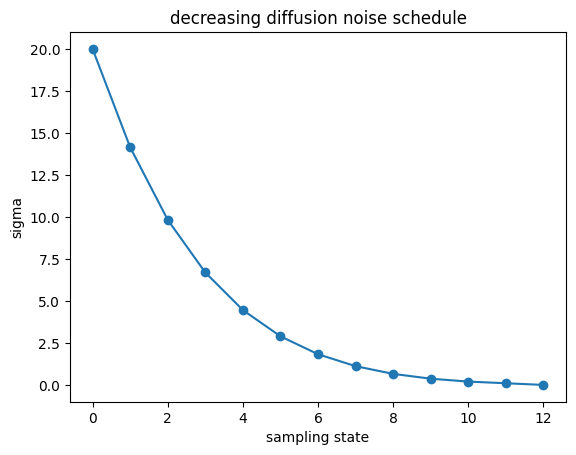

In [11]:
sampling_schedule = sample['schedule'].detach().cpu()
assert torch.all(sampling_schedule[1:] < sampling_schedule[:-1])
assert float(sampling_schedule[-1]) == 0.0

plt.plot(range(len(sampling_schedule)), sampling_schedule, marker='o')
plt.xlabel('sampling state')
plt.ylabel('sigma')
plt.title('decreasing diffusion noise schedule')
plt.show()

## Read the Predicted Structure

The sampler returns coordinates on the flattened atom axis. We'll reshape them back into residue-by-atom-slot form, remove the padded residue rows, and keep the sequence-derived atom mask that tells us which generated atom positions are valid.

In [12]:
atom_slot_count = len(ATOM_SLOTS)
predicted_atom_coords = sample['atom_coords'].view(
    1, folding_cfg.block_size, atom_slot_count, 3
)[0, :sequence_length].detach().cpu()
predicted_atom_mask = inference_batch['atom_mask_slots'][0, :sequence_length].detach().cpu()

assert torch.isfinite(predicted_atom_coords[predicted_atom_mask]).all()
predicted_atom_coords.shape, predicted_atom_mask.shape, predicted_atom_mask.sum()

(torch.Size([43, 37, 3]), torch.Size([43, 37]), tensor(210))

## Inspect Confidence Outputs

The confidence head gives us residue confidence through pLDDT, residue-pair alignment error through PAE, residue-pair distance error through PDE, and whole-structure TM-style scores. These values estimate the model's confidence in its own sampled structure; they are not calculated from the held-out target.

In [13]:
predicted_plddt = sample['predicted_plddt'][0, :sequence_length].detach().cpu()
predicted_aligned_error = sample['predicted_aligned_error'][0, :sequence_length, :sequence_length].detach().cpu()
predicted_distance_error = sample['predicted_distance_error'][0, :sequence_length, :sequence_length].detach().cpu()
predicted_tm = float(sample['predicted_tm'][0].detach().cpu())
predicted_iptm = float(sample['predicted_iptm'][0].detach().cpu())

predicted_plddt.shape, predicted_aligned_error.shape, predicted_distance_error.shape, predicted_tm, predicted_iptm

(torch.Size([43]),
 torch.Size([43, 43]),
 torch.Size([43, 43]),
 0.3226715624332428,
 0.3226715624332428)

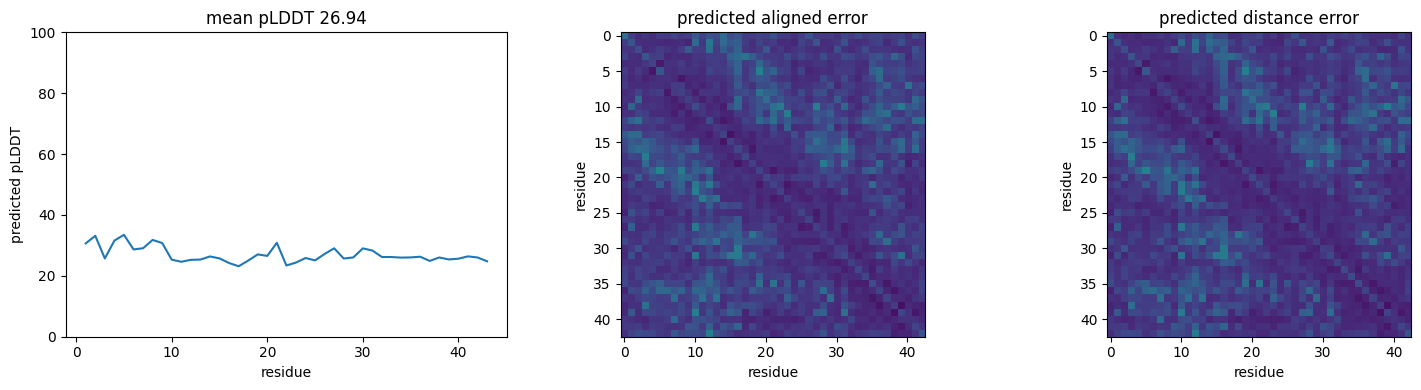

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(range(1, sequence_length + 1), predicted_plddt)
axes[0].set_ylim(0, 100)
axes[0].set_xlabel('residue')
axes[0].set_ylabel('predicted pLDDT')
axes[0].set_title(f'mean pLDDT {float(predicted_plddt.mean()):.2f}')
axes[1].imshow(predicted_aligned_error, vmin=0, vmax=32)
axes[1].set_title('predicted aligned error')
axes[1].set_xlabel('residue')
axes[1].set_ylabel('residue')
axes[2].imshow(predicted_distance_error, vmin=0, vmax=32)
axes[2].set_title('predicted distance error')
axes[2].set_xlabel('residue')
axes[2].set_ylabel('residue')
plt.tight_layout()
plt.show()

## Compare the Prediction Against the Target

Inference is complete, so now we can bring back the deposited test coordinates that we held out earlier. We'll write the prediction and target as separate atom-level PDB files. The predicted PDB stores residue pLDDT in the B-factor column so the confidence values travel with the structure.

In [15]:
example_name = f'{selected_shard_path.stem}_example_{selected_example_index:03d}'
predicted_pdb_path = output_root / f'{example_name}_predicted.pdb'
target_pdb_path = output_root / f'{example_name}_target.pdb'

write_atom_pdb(
    predicted_pdb_path,
    predicted_atom_coords,
    predicted_atom_mask,
    sequence,
    confidence=predicted_plddt,
)
write_atom_pdb(target_pdb_path, target_atom_coords, target_atom_mask, sequence)

#predicted_pdb_path, target_pdb_path

### Target and Predicted Ribbons

The target structure is shown on the left and the sampled prediction is shown on the right. Ribbon rendering uses the backbone atoms written to each PDB. If the prediction is still poor, its ribbon may look fragmented or geometrically unrealistic even though the inference path produced finite atom coordinates.

In [16]:
view = py3Dmol.view(width=900, height=560)
view.addModel(target_pdb_path.read_text(), 'pdb')
view.setStyle({}, {'cartoon': {'color': 'gray'}})
view.addStyle({}, {'stick': {'radius': 0.14, 'colorscheme': 'Jmol', 'opacity': 0.45}})
view.addStyle({}, {'sphere': {'scale': 0.22, 'colorscheme': 'Jmol', 'opacity': 0.45}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [17]:
view2 = py3Dmol.view(width=900, height=560)
view2.addModel(predicted_pdb_path.read_text(), 'pdb')
view2.setStyle({}, {'cartoon': {'color': 'spectrum'}})
view2.addStyle({}, {'stick': {'radius': 0.14, 'colorscheme': 'Jmol', 'opacity': 0.45}})
view2.addStyle({}, {'sphere': {'scale': 0.22, 'colorscheme': 'Jmol', 'opacity': 0.45}})
view2.zoomTo()
view2.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Conclusion

We've now run a held-out sequence through the complete inference path. The test shard supplied the sequence, but the model rebuilt its inference features without using the deposited target coordinates. From there the folding core created the pair representation, diffusion sampled atom coordinates across the full noise schedule, and the confidence head scored the final prediction. The cached target only returned after inference so we could inspect the two structures side by side.